In [14]:
# =========================
# 0) IMPORTACIONES
# =========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.multioutput import MultiOutputClassifier
from sklearn.base import clone

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    hamming_loss,
    jaccard_score,
    make_scorer
)

from sklearn.preprocessing import MultiLabelBinarizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", context="notebook")

In [ ]:
RUTA_TRAIN = "Datos_Laboratorio3.csv"
RUTA_TEST = "Datos test Lab3.csv"

df = pd.read_csv(RUTA_TRAIN, sep=";", encoding="latin-1")
df_test = pd.read_csv(RUTA_TEST, sep=";", encoding="latin-1")

print("Dimensiones del conjunto de entrenamiento:", df.shape)
print("Dimensiones del conjunto de prueba:", df_test.shape)
print("\nColumnas:\n", df.columns.tolist())

display(df.head())
df.info()
display(df.describe(include="all").T)

Dimensiones del conjunto de entrenamiento: (9698, 26)
Dimensiones del conjunto de prueba: (302, 26)

Columnas:
 ['Edad', 'Gnereo', 'Peso', 'Altura', 'BMI', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Horas_sueño', 'Entrenamiento_preferido', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua', 'Plan_entrenamiento', 'Plan_nutrición']


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,Funcional,3,98,0,0,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,Funcional,4,105,0,0,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,Fuerza,1,88,0,0,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,Funcional,5,96,0,0,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,Balance,3,120,0,1,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


<class 'pandas.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Gnereo                   9698 non-null   str    
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   str    
 6   Condicion_salud          9698 non-null   str    
 7   Nivel_Actividad          9698 non-null   str    
 8   Nivel_experiencia        9698 non-null   str    
 9   Dieta_preferida          9698 non-null   str    
 10  Horas_sueño              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   str    
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia            9698 non-n

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Edad,9698.0,NaN,NaN,NaN,45.112601,17.641045,15.0,30.0,45.0,61.0,75.0
Gnereo,9698,3,Femenino,4719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Peso,9687.0,NaN,NaN,NaN,92.622515,27.383913,45.0,68.8,92.6,116.5,140.0
Altura,9698.0,NaN,NaN,NaN,1.775047,0.158754,1.5,1.64,1.78,1.91,2.05
BMI,9698.0,NaN,NaN,NaN,30.131391,10.605675,10.93,21.62,29.19,37.06,62.09
Objetivo,9698,5,Ganancia muscular,2757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condicion_salud,9698,7,Ninguno,6030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nivel_Actividad,9698,3,Moderado,3594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nivel_experiencia,9698,3,Intermedio,4100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dieta_preferida,9698,5,No-Vegetariano,2456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
faltantes = df.isna().sum().sort_values(ascending=False)
duplicados = df.duplicated().sum()

print("Duplicados:", duplicados)
print("\nValores faltantes por columna:\n")
display(faltantes.to_frame("n_faltantes"))

unicos = df.nunique().sort_values()
display(unicos.to_frame("n_unicos"))

Duplicados: 0

Valores faltantes por columna:



,n_faltantes
Peso,11
Edad,0
Tiene_alergia,0
Plan_entrenamiento,0
Ingesta_agua,0
Pasos_dia,0
Ingesta_proteinas,0
Score_micronutrientes,0
Alcohol_semana,0
Alcohol,0


,n_unicos
Alcohol,2
Fumador,2
Problemas_digestivos,2
Tiene_alergia,2
Gnereo,3
Nivel_Actividad,3
Nivel_experiencia,3
Plan_nutrición,4
Plan_entrenamiento,4
Objetivo,5


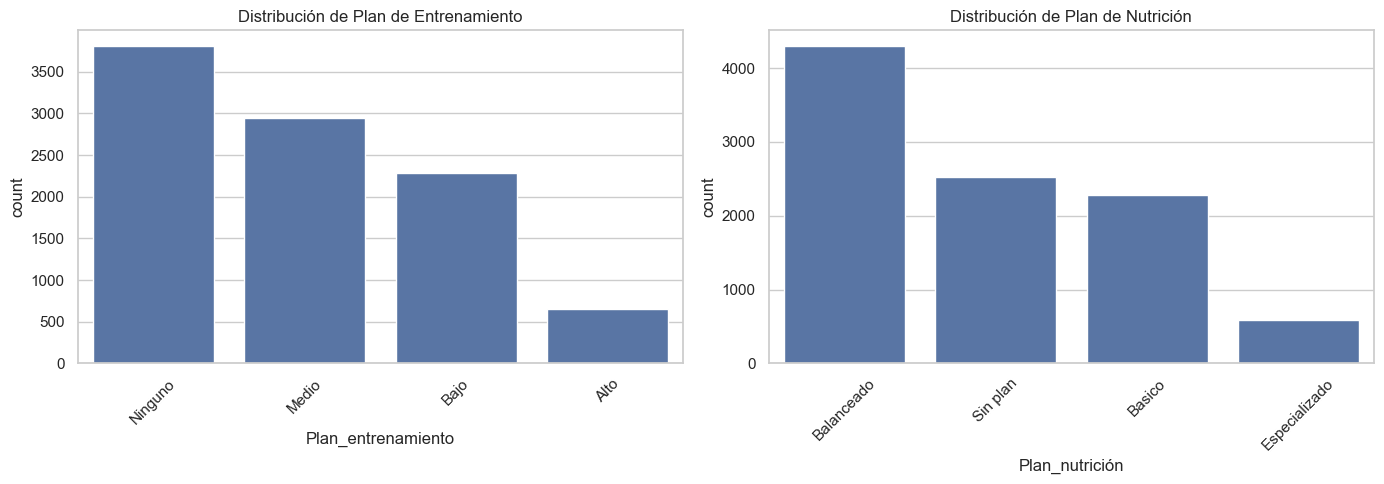

Distribución Plan de Entrenamiento:


,proporción
Plan_entrenamiento,
Ninguno,0.392555
Medio,0.303671
Bajo,0.236131
Alto,0.067643


Distribución Plan de Nutrición:


,proporción
Plan_nutrición,
Balanceado,0.443081
Sin plan,0.260054
Basico,0.235822
Especializado,0.061044


In [17]:
TARGET_ENTRENAMIENTO = "Plan_entrenamiento"
TARGET_NUTRICION ="Plan_nutrición"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=TARGET_ENTRENAMIENTO, order=df[TARGET_ENTRENAMIENTO].value_counts().index, ax=axes[0])
axes[0].set_title("Distribución de Plan de Entrenamiento")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x=TARGET_NUTRICION, order=df[TARGET_NUTRICION].value_counts().index, ax=axes[1]) 
axes[1].set_title("Distribución de Plan de Nutrición")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Distribución Plan de Entrenamiento:")
display(df[TARGET_ENTRENAMIENTO].value_counts(normalize=True).rename("proporción").to_frame())

print("Distribución Plan de Nutrición:")
display(df[TARGET_NUTRICION].value_counts(normalize=True).rename("proporción").to_frame())

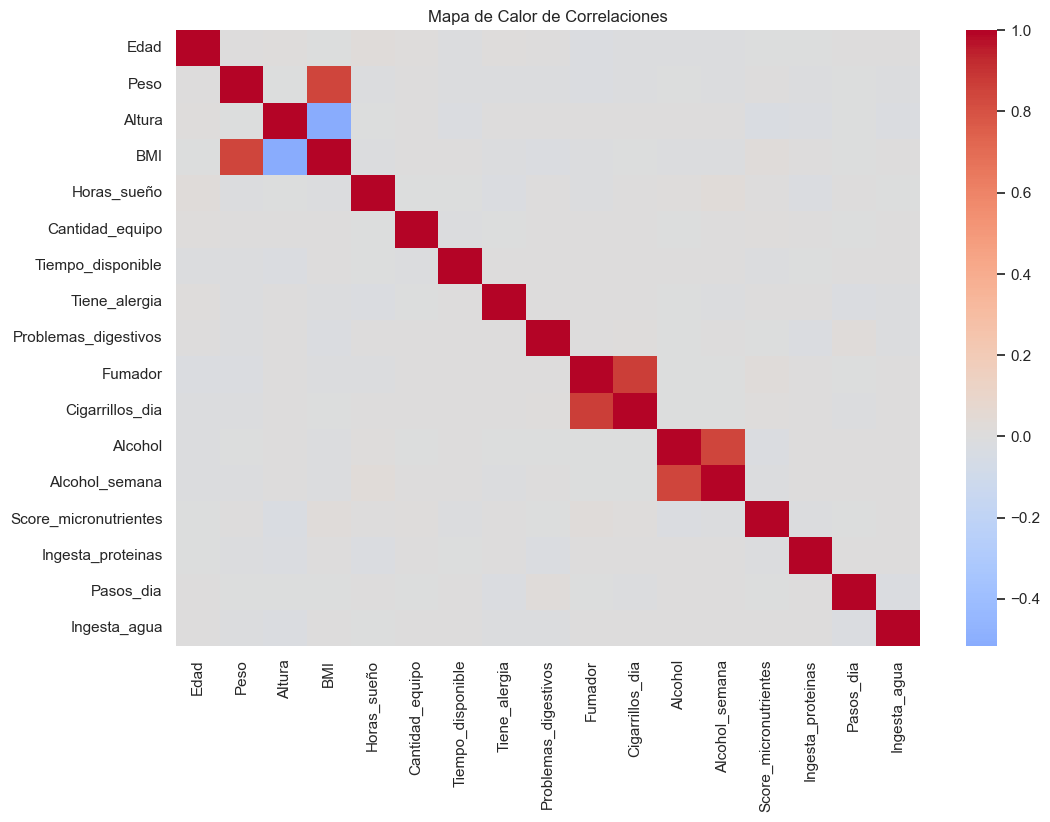

In [18]:
num_cols_tmp = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
corr = df[num_cols_tmp].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [19]:
TARGETS = [TARGET_ENTRENAMIENTO, TARGET_NUTRICION]

X = df.drop(columns=TARGETS)
y_ent = df[TARGET_ENTRENAMIENTO].copy()
y_nut = df[TARGET_NUTRICION].copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Columnas numéricas:", len(num_cols), num_cols)
print("Columnas categóricas:", len(cat_cols), cat_cols)

Columnas numéricas: 17 ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
Columnas categóricas: 7 ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']


In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [21]:
def entrenar_y_evaluar_objetivo(
    X, y, target_name, modelo_nombre, modelo_base, param_grid,
    preprocessor, random_state=42, test_size=0.2, cv_folds=5, scoring="f1_weighted"
):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo_base)
    ])
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    resultados = {
        "objetivo": target_name,
        "modelo": modelo_nombre,
        "cv_best_score_f1_weighted": grid.best_score_,
        "test_precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "best_params": grid.best_params_
    }
    
    artefactos = {
        "grid": grid,
        "best_model": best_model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred
    }
    
    return resultados, artefactos

In [22]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=6000)

param_grid_log= [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["lbfgs", "newton-cg"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["elasticnet"],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    }
]

resumen_resultados = []
artefactos_modelos = {}

for target_name, y_obj in [(TARGET_ENTRENAMIENTO, y_ent), (TARGET_NUTRICION, y_nut)]:
    res, art = entrenar_y_evaluar_objetivo(
        X=X,
        y=y_obj,
        target_name=target_name,
        modelo_nombre="RegresionLogistica",
        modelo_base=log_reg,
        param_grid=param_grid_log,
        preprocessor=preprocessor,
        random_state=RANDOM_STATE,
        test_size=0.30,
        cv_folds=5,
        scoring="f1_weighted"
    )
    resumen_resultados.append(res)
    artefactos_modelos[(target_name, "RegresionLogistica")] = art
    
    print(f"\n===== {target_name} | RegresionLogistica =====")
    print("Mejores hiperparámetros:")
    print(res["best_params"])
    print("\nClassification report (test):")
    print(classification_report(art["y_test"], art["y_pred"], zero_division=0))
    

Fitting 5 folds for each of 72 candidates, totalling 360 fits

===== Plan_entrenamiento | RegresionLogistica =====
Mejores hiperparámetros:
{'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}

Classification report (test):
              precision    recall  f1-score   support

        Alto       0.90      0.85      0.87       197
        Bajo       0.80      0.79      0.80       687
       Medio       0.89      0.89      0.89       884
     Ninguno       0.94      0.95      0.95      1142

    accuracy                           0.89      2910
   macro avg       0.88      0.87      0.88      2910
weighted avg       0.89      0.89      0.89      2910

Fitting 5 folds for each of 72 candidates, totalling 360 fits

===== Plan_nutrición | RegresionLogistica =====
Mejores hiperparámetros:
{'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}

Classification report (test):
               precision    recall  f1-